# DSP Methodology

In [1]:
%matplotlib widget

import sys; sys.path.insert(0, '../../../research')
from dsplot.figures import figure_1, figure_2_4_1


## 1. Motivations
- To visualize an audio signal effectively, we need an extremely precise method for representing it's behavior
- Specifically, we want to know **what** frequencies are present and **when** they occur in the signal - this is the primary motivation for finding a highly accurate **time-frequency** analysis method 
  - The standard approach is to use the **Fourier Transform**, but in this context it has limitations
  - The more recent **Wavelet Transform** was basically designed for this kind of task

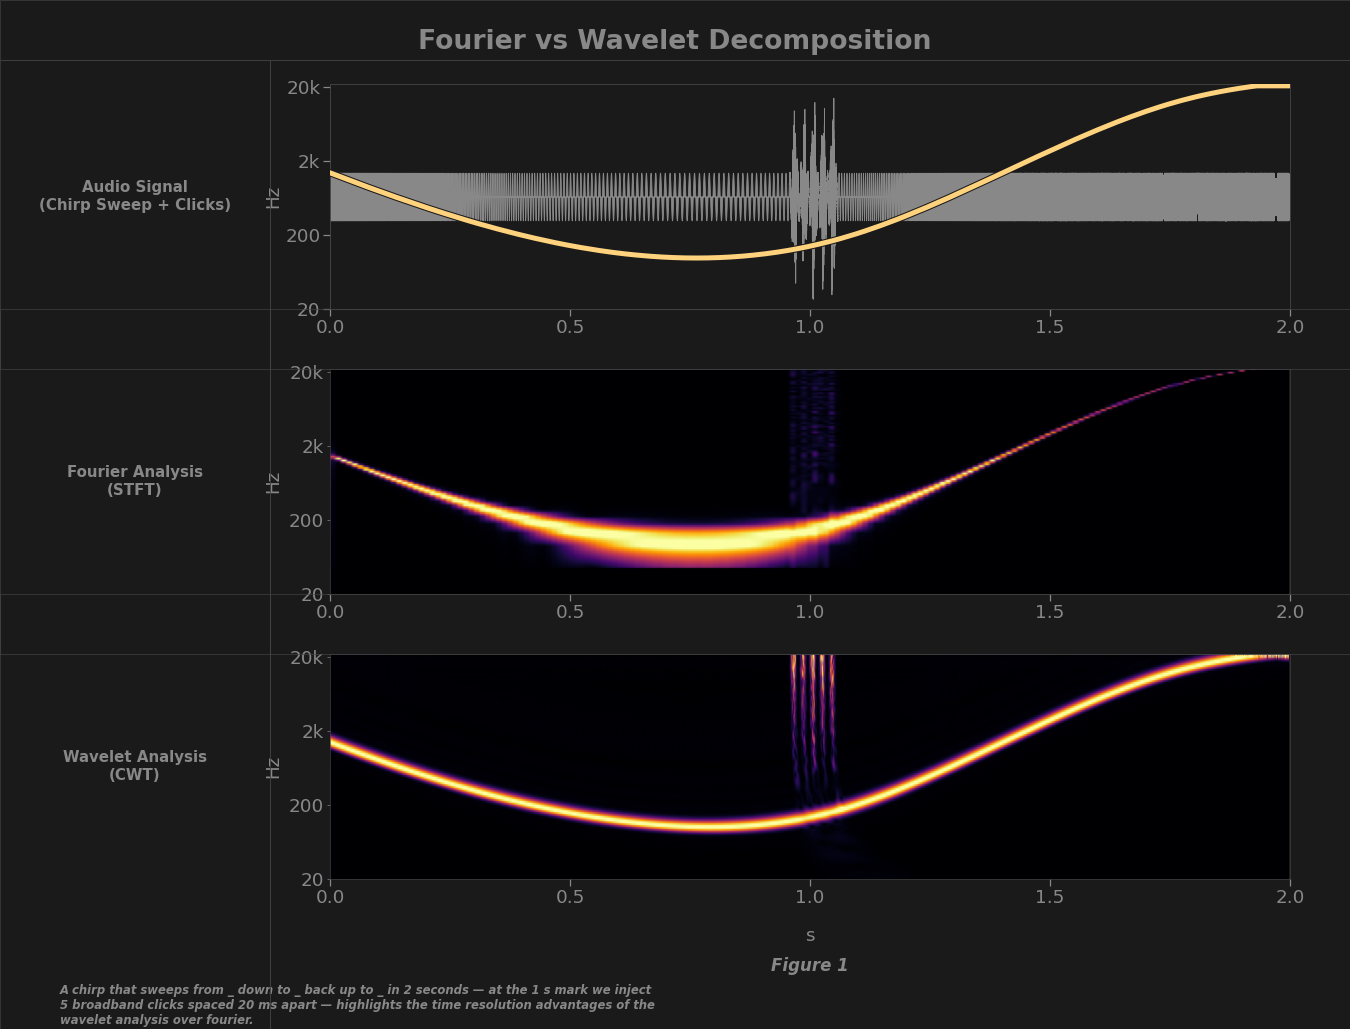

In [2]:
figure_1()


- Both are built on the same foundation - **signal decomposition** 
- Beginning with simple examples, we will build up to a comprehensive and intuitive understanding of how these methods actually work, and explore the different areas where they excel and fall short

---

## 2. Foundations

### 2.1 Signal Decomposition - The Goal

- The end goal is to **decompose** any given signal into its fundamental **components**
- In simpler terms, we want to break it down into its **basic building blocks** and see how much of each exists in the signal originally 
- This is like trying to unmix a can of paint to figure out how much of each color ingredient contributed to the overall color of the paint - where would you even begin?
- This type of problem motivates us to do two things:
    1. **Define what a signal's fundamental components are** 
    2. **Measure the presence of each component in the signal** 
- This is where the **Inner Product** comes into play - it's a general-purpose tool for measuring signal components, and we will explore these two motivations in different contexts


### 2.2 Inner Product - The Tool

- The **Inner Product** gives us a generic way to compare a function **f** (the signal) and a reference function **g** (something that embodies the signal properties we want to measure) to calculate, effectively, a "**similarity score**"

<div align="center">

$$
\langle \, 
\mathbf{f} \, , \, 
\mathbf{g} \,
\rangle 
$$

<em>Inner Product Notation</em>

</div>

- The result is a measurement of how **correlated** these function are, indicating their **similarity**
- But to understand how this actually works, it's helpful to see how the Inner Product operates in its simplest form: the **Dot Product**



### 2.3 Dot Product - The Basic Case

- The Inner Product is a generalization of what the **Dot Product** does to **vectors** in $\mathbb{R}^n$ 
- All this means is we'll be applying these concepts to just plain, regular, real numbers - no imaginary or abstract numbers in weird math domains (yet)
- As long as you can do basic **multiplication** and **addition**, it's really not too bad

<div align="center">

$$
\vec{a} \cdot\vec{b} = \sum_{i=0}^{n} a_i b_i
$$

<em>Dot Product Notation</em>
</div>

- Read this as: "Multiply each term in vector **a** with each term in vector **b** and then add them all up"
    <!-- 1. Take the first term from **a** 
    2. Take the first term from **b**
    3. **Multiply** them together
    4. Repeat 1-3 for each pair of terms
    5. **Add** up all the multiplied terms together -->

<div align="center">

$$
\vec{a} = 
    ( \,
    a_0 \, , \,
    a_1 \, , \,
    a_2 \, , \, 
    \ldots \, , \,
    a_n \, )
$$

</div>

<div align="center">

$$
\vec{b} = 
    ( \,
    b_0 \, , \,
    b_1 \, , \,
    b_2 \, , \, 
    \ldots \, , \,
    b_n \, )
$$

</div>

<div align="center">

$$
\vec{a} \cdot\vec{b} = 
    a_0 \cdot b_0 \, + \,
    a_1 \cdot b_1 \, + \,
    a_2 \cdot b_2 \, + \, 
    \ldots \, + \,
    a_n \cdot b_n \, 
$$

<em> Dot Product Operation </em>
</div>

- But what does this result even really mean? And what does this operation even really do? 
- The result indicates how **parallel** vectors **a** and **b** are - this is the key insight to understanding that the Dot Product operation measures **"similarity"** by  calculating how **aligned** **a** and **b** are in terms of their parallel-ness so to speak
- This clicks more visually during **Vector Projection**, our first attempt at any form of **decomposition**


### 2.4 Vector Projection - The Geometric Interpretation

#### 2.4.1 Projection onto a Reference Direction

- A **vector** can be thought of as an **arrow** described by two of its properties
  - **magnitude** - how long it is 
  - **direction** - where it points

- To decompose a vector (break it down into its basic components) we **project it along the directions** of all the dimensions it exists in - think of it like the vector casting its **"shadow"** onto the x and y axes  



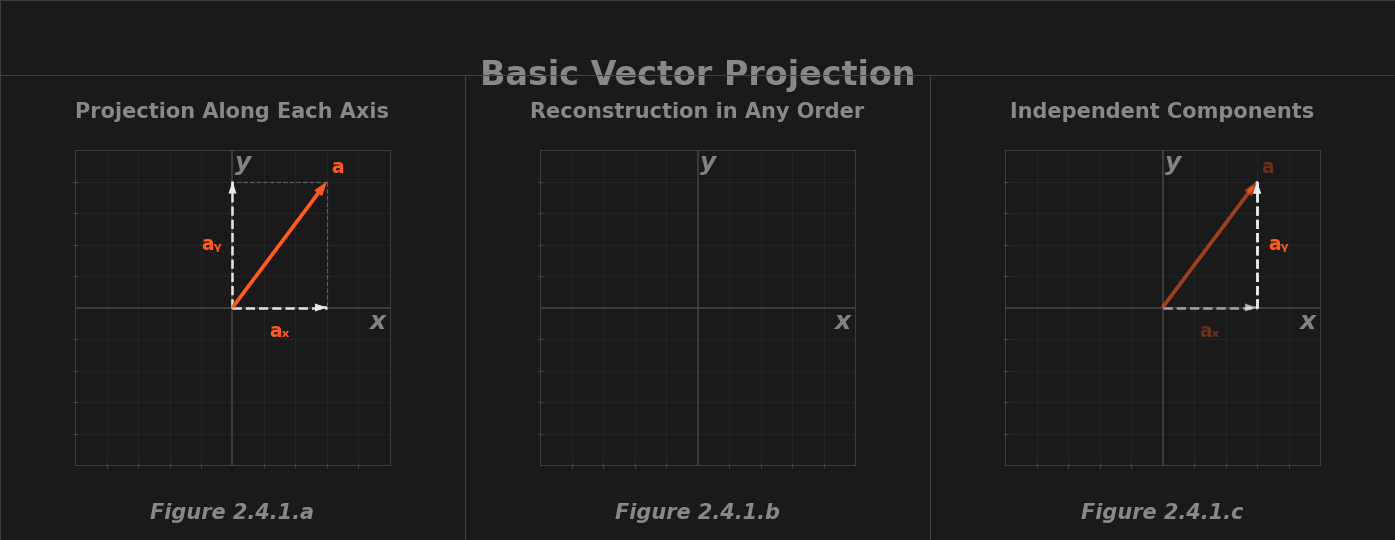

In [3]:
figure_2_4_1()

- The **length** of each "shadow" *is* the vector's **basic component** for that dimension and reveals each dimension's **contribution** to the original as a whole <!-- - the axes these shadows casted upon are at **right angles** so these vector components are **independent** of one another -->
- Important to note that each component
  - **Can be combined in any order** to reconstruct the original - when rebuilding them tip-to-tail, regardlessly if starting with x first and then y, or y first and then x, you still end up with the original  
  - **Cannot be described in terms of each other** - geometrically x and y are at right angles, meaning they ar
  
  meaning any change in value for the x component does not affect, and goes completely unnoticed by the y component

#### 2.4.2 Projection onto Another Vector
- So being able to project onto the X and Y axis is great however the theme or the central message that we are trying to keep pushing is finding a way to describe how much of something is present in another thing right how much of a certain property is present in a composite thing and this is basically our first attempt at doing anything like that because when you 

- When projecting one vector onto another, like **a** onto **b**, we use **b** as the **reference direction**, which reveals the components of **a** that are **aligned** with, or parallel to **b** 

- The more **parallel** the two vectors are, the larger **a**'s projetion onto **b** is

- When performing the Dot Product on these components, the result encapsulates these components overall alignments

In [4]:
# figure_2_4_2()


<!-- ![Projection of a onto b (left) and b onto a (right), each shown with both reconstruction paths — parallel-then-perp and perp-then-parallel — demonstrating order independence for any reference direction](../../../assets/images/dsp/figures/projection_reconstruction/either_order_v9.png) -->

- Notice how when we project **a** onto **b** or **b** onto **a**, the resulting __ [the visual annotates each component of each projection - do the math for each exmaple - display how the dot product in either case produces the same result - this basically means we don't really care which one is the reference dimension - show math example in the with each - ]
<!-- WRITE 2.4.1 beat 4 — symmetry of the dot product (right panel).
     Even though "a onto b" and "b onto a" produce visibly different
     shadows (different lengths along different reference directions), the
     scalar dot product comes out the same: a · b = b · a. The reference
     direction is your choice; the answer doesn't care.
     The figure carries this in two juxtaposed panels — same a, same b,
     reference direction flipped, with the matching a · b = 12 dot
     product result substituted in the LaTeX block below. -->

<div align="center">

$$
\vec{a} = (a_x,\, a_y) = (2,\, 3) \qquad \vec{b} = (b_x,\, b_y) = (3,\, 2)
$$

$$
\vec{a} \cdot \vec{b} = a_x b_x + a_y b_y = (2)(3) + (3)(2) = 6 + 6 = 12
$$

$$
\vec{b} \cdot \vec{a} = b_x a_x + b_y a_y = (3)(2) + (2)(3) = 6 + 6 = 12
$$

</div>

- [This actually works because of the symmetry found the geometry of the triangle these two vectors make - this the area equation of a triangle - watch this video to see how it relates to the Dot Product - but otherwise just trust they can be derived from each other link - https://www.youtube.com/watch?v=PnJoKGynu_U]

<!-- ![Four canonical angles between a and b: parallel-same → positive, parallel-opposite → negative, perpendicular → zero, oblique → partial](../../../assets/images/dsp/figures/dot_product/geometry.png) -->

- The projection's magnitude tells us how aligned **b** and **a** are. Three extreme cases:
    - **parallel + same direction** → full projection → large positive result
    - **parallel + opposite direction** → flipped projection → large negative result
    - **perpendicular** → no projection → zero result
    
<!-- WRITE 2.4.1 beat 5 — angle controls sign and magnitude.
     The projection's magnitude AND sign depend on the angle between the
     two vectors. Four canonical cases land it:
       - parallel + same direction → max positive result
       - parallel + opposite direction → max negative result
       - perpendicular → zero
       - oblique (anything in between) → partial result, sign matches
         whether they "lean toward each other" or "lean apart"
     This is the angle → sign mapping the dot product gives you for free. -->



#### 2.4.3 Beyond 2D — Same Operation, More Dimensions

<!-- WRITE 2.4.2 beat 1 — 3D, with the figure as the visual proof.
     The same operation extends to 3D unchanged: pick reference directions
     (now x, y, z), project a onto each, get three components. Concrete
     example to walk through:
       a · b = a₁b₁ + a₂b₂ + a₃b₃    (same multiply-and-sum, one more term)
     Then call out what the figure also reveals: the components can be
     recombined in any order — the orange path (x → y → z) and the blue
     path (z → y → x) both arrive at the same tip a. Order independence
     is a property of the projection, not an accident of 2D. -->

![Vector a in 3D, decomposed into x/y/z components, recombined in two different orders (x→y→z and z→y→x) — both paths arrive at the same tip](../../../assets/images/dsp/figures/vector_projection_3d/v2_combo5_palette.png)

<!-- WRITE 2.4.2 beat 2 — ND reframe (locked bridge sentence).
     Polish this sentence — the locked phrasing is:
       "Notice how the pattern in two dimensions applied to three
        dimensions, and the pattern expands to any number of n — but we
        can't really visualize n dimensions, so we'll drop that
        terminology and think of it in terms of N pair-wise multiplications
        whose sign agreements accumulate into one running total."
     Let "n dimensions" be the geometric framing we leave behind, and
     "N pair-wise multiplications" be the algebraic framing we carry into
     §2.5. -->

<!-- WRITE 2.4.2 beat 3 — handoff into §2.5.
     One-sentence pivot: we've been treating the dot product as one
     number, but it's built from N signed products — and the signs do
     most of the work. The next section opens up the sum and watches the
     agreement accumulate. -->

### 2.5 Sign Accumulation - The Agreement Mechanism

<!-- WRITE 2.5 lead-in — pick up where §2.4.2 left off.
     The dot product is a signed similarity accumulator. Each pair of
     matching components contributes one signed product to a running
     total. The signs do the voting. -->

- Dot product is a signed similarity accumulator
- Same signs → positive contribution (agreement)
- Opposite signs → negative contribution (disagreement)
- Final sum = net agreement across all elements
- This process of measuring similarity between two sequences is called **correlation**

*[Interactive: color-coded element products]*

### 2.6 Basis Functions - Achieving Signal Decomposition

- Accomplishing this really depends on the signal being analyzed and the properties we're interested in measuring
- The function we compare against is called a **basis function** - a known reference **pattern**
- The choice of basis function determines what features we can detect
- The scalar result of this comparison is called a **coefficient** - it tells you "how much" of that basis function is present

<!-- FIGURE relocated here from §2.4 per the consolidation pass — once §2.6
     is being authored, place the tip-to-tail recombination panel where it
     reinforces "components form a basis": the same components recombined
     in different orders both reconstruct a, which is exactly the property
     a basis function family relies on.
     ![Same components recombined tip-to-tail in opposite orders both reconstruct a](../../../assets/images/dsp/figures/vector_xy_reconstruction/baseline.png)
-->

This is all about re-representing **all the information** from the original signal into a **different format**, while also being able to perform the **reverse process** to **reconstruct** the original  

---

## 3. Fourier Transform: Sinusoidal Basis Functions
